In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/08_investor_transactions.csv")
print(df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [3]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Check data types
df.dtypes

# Save cleaned dataset
df.to_csv(
    "../data/processed/dataset8_cleaned.csv",
    index=False
)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [4]:
df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [5]:
df.isnull().sum()

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

investor_id               str
transaction_date          str
amfi_code               int64
transaction_type          str
amount_inr              int64
state                     str
city                      str
city_tier                 str
age_group                 str
gender                    str
annual_income_lakh    float64
payment_mode              str
kyc_status                str
dtype: object

In [8]:
df.describe()

,amfi_code,amount_inr,annual_income_lakh
count,32778.000000,32778.000000,32778.000000
mean,120264.617518,107437.318628,26.181219
std,14370.205345,150415.905084,20.805425
min,100016.000000,400.000000,3.000000
25%,118632.000000,3153.000000,10.600000
50%,119551.000000,17782.500000,19.700000
75%,120843.000000,189324.250000,37.400000
max,149324.000000,597498.000000,99.700000


In [11]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df.dtypes

investor_id                      str
transaction_date      datetime64[us]
amfi_code                      int64
transaction_type                 str
amount_inr                     int64
state                            str
city                             str
city_tier                        str
age_group                        str
gender                           str
annual_income_lakh           float64
payment_mode                     str
kyc_status                       str
dtype: object

In [12]:
df["investor_id"].nunique()

5000

In [13]:
df["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [14]:
df["amount_inr"].describe()

count     32778.000000
mean     107437.318628
std      150415.905084
min         400.000000
25%        3153.000000
50%       17782.500000
75%      189324.250000
max      597498.000000
Name: amount_inr, dtype: float64

In [15]:
df["state"].value_counts()

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Rajasthan         2577
Maharashtra       2524
Name: count, dtype: int64

In [16]:
df["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

In [17]:
df["payment_mode"].value_counts()

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

In [18]:
df["kyc_status"].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

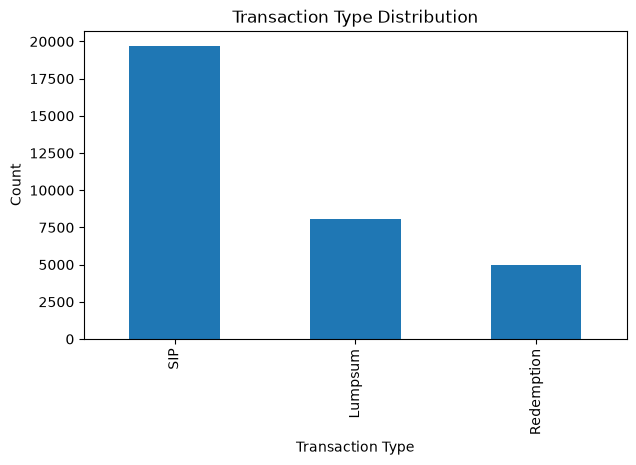

In [19]:
import matplotlib.pyplot as plt

df["transaction_type"].value_counts().plot(kind="bar", figsize=(7,4))

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

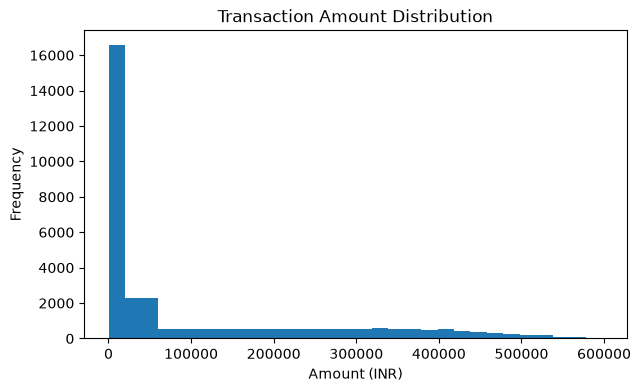

In [20]:
plt.figure(figsize=(7,4))

plt.hist(df["amount_inr"], bins=30)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")

plt.show()

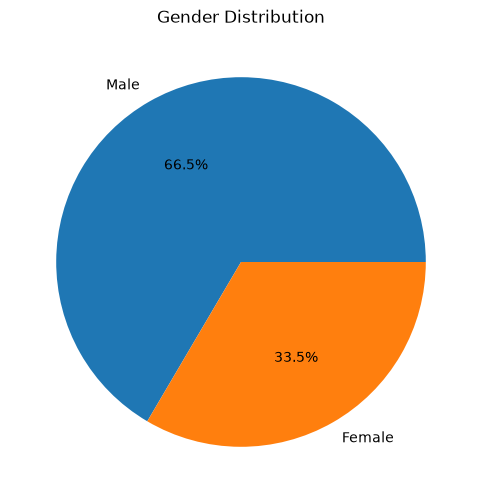

In [21]:
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

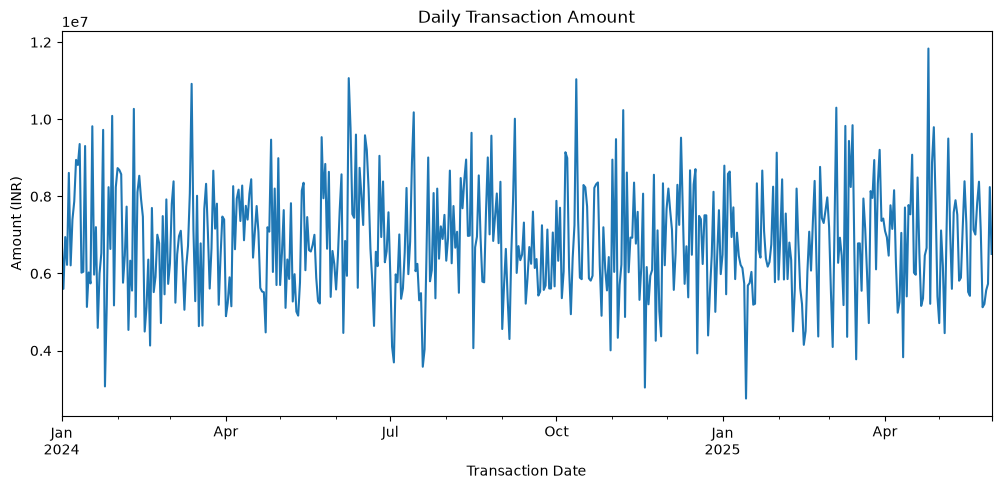

In [22]:
daily = df.groupby("transaction_date")["amount_inr"].sum()

daily.plot(figsize=(12,5))

plt.title("Daily Transaction Amount")

plt.xlabel("Transaction Date")

plt.ylabel("Amount (INR)")

plt.show()

## Insights from Portfolio Holdings Dataset

## Dataset Overview

The dataset contains mutual fund portfolio holdings details including stock information, sector classification, portfolio weight, market value and current stock prices.

## Data Quality

No missing values and duplicate records were identified.

Data types were checked and the portfolio date column was converted into proper datetime format.

## Portfolio Analysis

Sector-wise allocation analysis helps understand fund diversification across different industries.

Top holdings were identified based on portfolio weight percentage.

Market value contribution of different sectors was analyzed to identify major investment areas.

Portfolio distribution shows exposure towards sectors such as Banking, IT, Pharma, Automobile and Utilities.

## Observation

This dataset helps analyze portfolio composition, sector allocation, stock concentration and investment patterns of mutual funds.

The analysis provides insights into diversification and major contributors to overall portfolio value.